In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from  sklearn.linear_model import LinearRegression
from  sklearn.tree import DecisionTreeRegressor
from  sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from  sklearn.metrics import mean_squared_error 
from  sklearn.metrics import r2_score

import warnings
warnings.filterwarnings("ignore")



In [6]:
# fixed Windows path (use raw string or forward slashes)
df = pd.read_csv(r"C:\Users\User\Downloads\house_price_regression_dataset.csv")


In [4]:
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [5]:
df.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='str')

In [6]:
df.shape

(1000, 8)

In [7]:
df.size

8000

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [9]:
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [10]:
for col in df.columns:
    if df[col].nunique() <=10:
        print(f"\nColumn: {col}")
        print(df[col].unique())


Column: Num_Bedrooms
[2 3 1 5 4]

Column: Num_Bathrooms
[1 3 2]

Column: Garage_Size
[0 1 2]

Column: Neighborhood_Quality
[ 5  6  9  8  1  2  4 10  7  3]


In [11]:
df.isnull().sum()

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

In [12]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


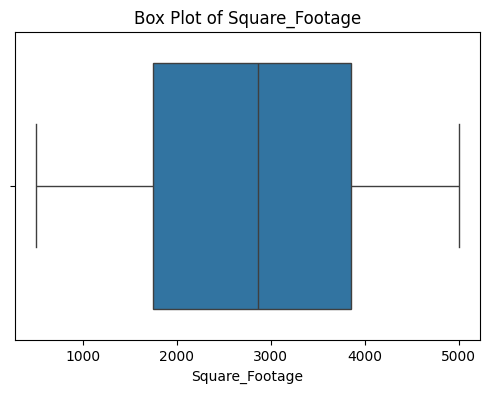

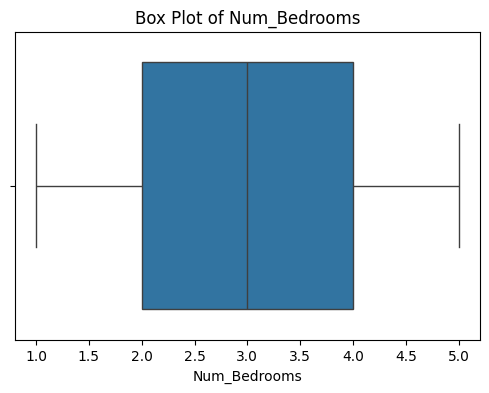

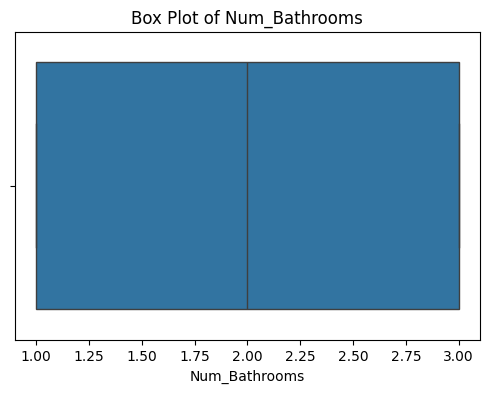

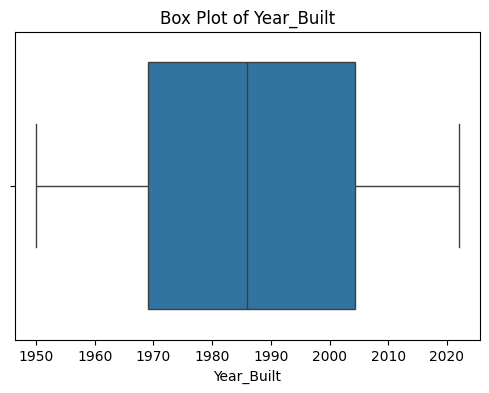

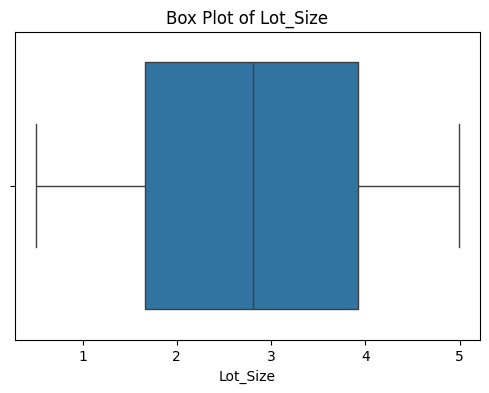

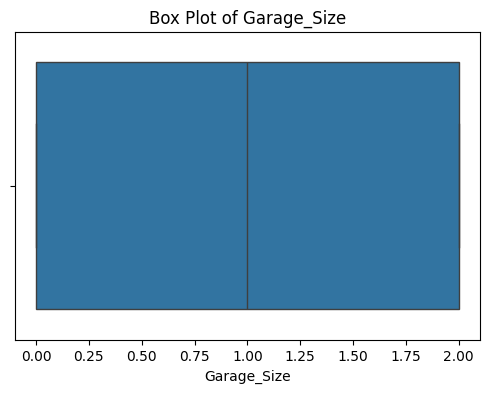

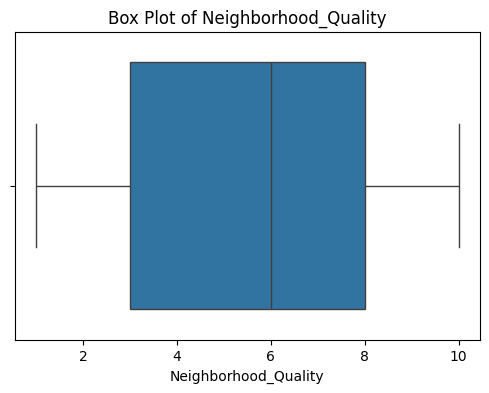

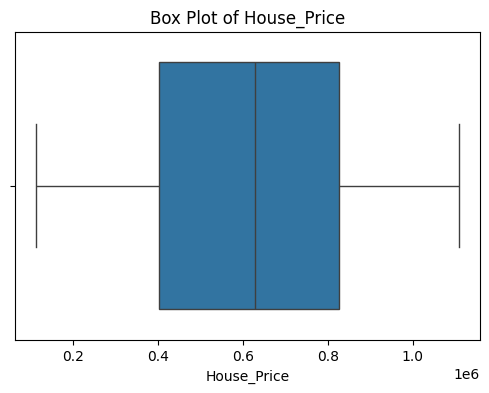

In [13]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Box Plot of {col}")
    plt.show()

In [14]:
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()
corr

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
Square_Footage,1.000000,-0.043564,-0.031584,-0.022392,0.089479,0.030593,-0.008357,0.991261
Num_Bedrooms,-0.043564,1.000000,0.022848,-0.015820,-0.009355,0.113761,-0.049024,0.014633
Num_Bathrooms,-0.031584,0.022848,1.000000,-0.021063,0.034923,0.024846,0.017585,-0.001862
Year_Built,-0.022392,-0.015820,-0.021063,1.000000,-0.061050,-0.025485,-0.009549,0.051967
Lot_Size,0.089479,-0.009355,0.034923,-0.061050,1.000000,0.002436,0.037630,0.160412
Garage_Size,0.030593,0.113761,0.024846,-0.025485,0.002436,1.000000,-0.011287,0.052133
Neighborhood_Quality,-0.008357,-0.049024,0.017585,-0.009549,0.037630,-0.011287,1.000000,-0.007770
House_Price,0.991261,0.014633,-0.001862,0.051967,0.160412,0.052133,-0.007770,1.000000


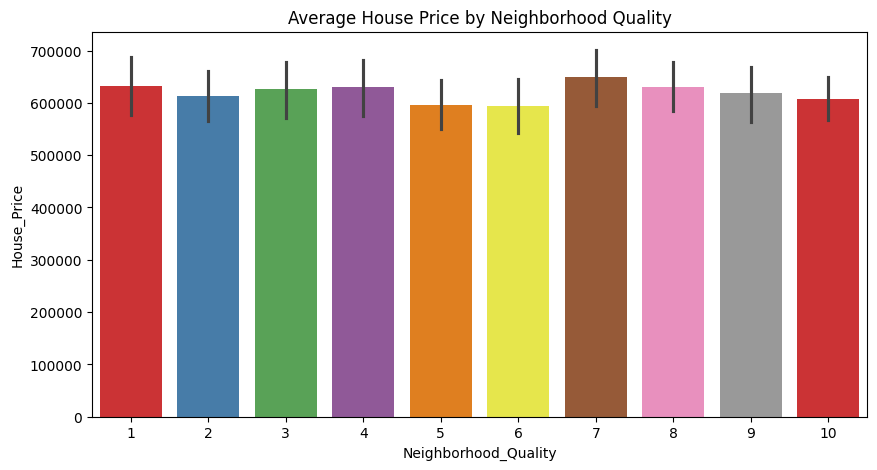

In [15]:
plt.figure(figsize=(10,5))
sns.barplot(x="Neighborhood_Quality", y="House_Price",data=df,palette='Set1') 
plt.title("Average House Price by Neighborhood Quality")
plt.show()


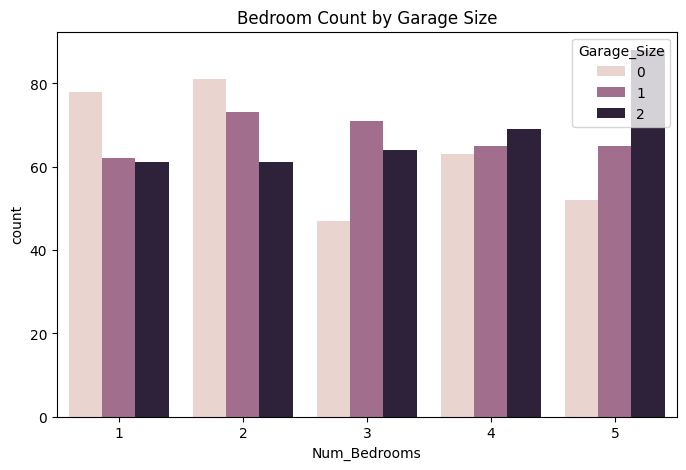

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(x="Num_Bedrooms", hue="Garage_Size",data=df) 
plt.title("Bedroom Count by Garage Size")
plt.show()

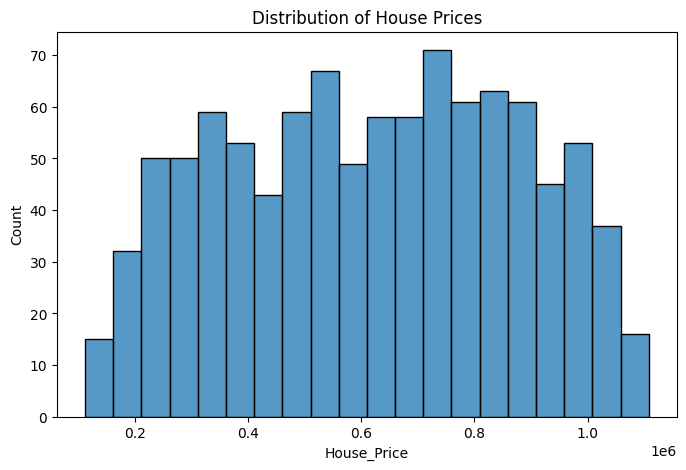

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df["House_Price"],bins=20,kde=False) 
plt.title("Distribution of House Prices")
plt.show()

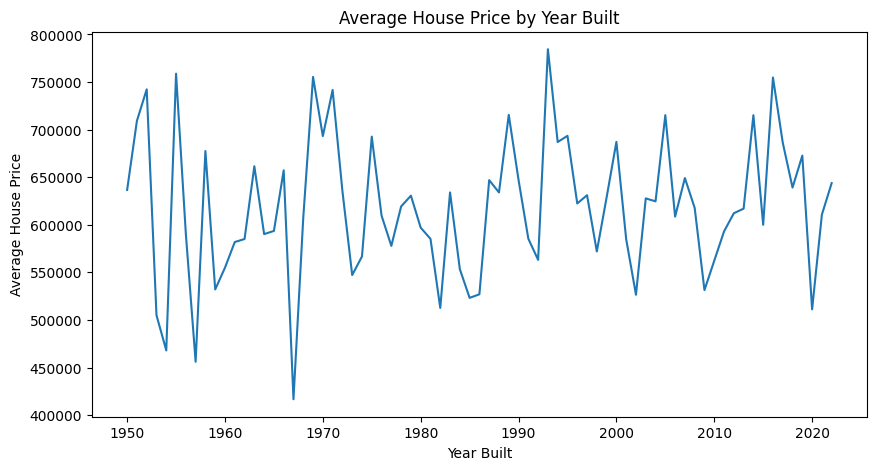

In [19]:
year_price = df.groupby("Year_Built")["House_Price"].mean()
plt.figure(figsize=(10,5))
plt.plot(year_price.index,year_price.values)
plt.title("Average House Price by Year Built")
plt.xlabel("Year Built")
plt.ylabel("Average House Price")
plt.show()

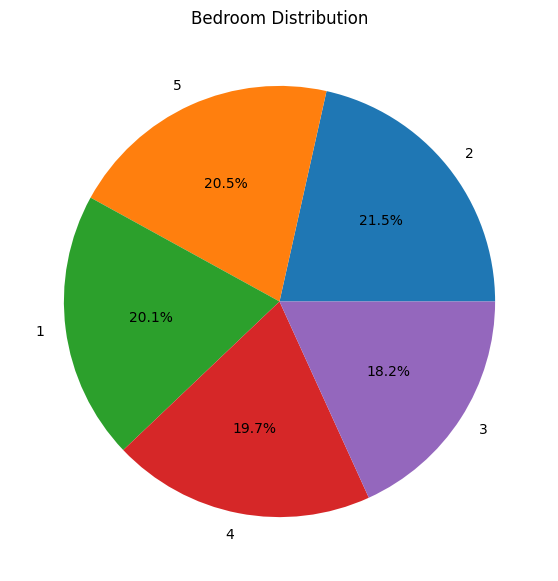

In [20]:
bedroom_counts = df["Num_Bedrooms"].value_counts()
plt.figure(figsize=(7,7))
plt.pie(bedroom_counts,labels=bedroom_counts.index,autopct="%1.1f%%")
plt.title("Bedroom Distribution")
plt.show()

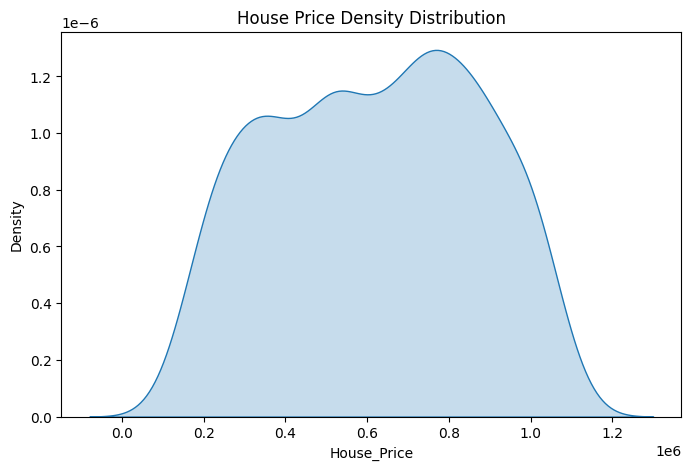

In [21]:
plt.figure(figsize=(8,5))
sns.kdeplot(df["House_Price"],fill=True)
plt.title("House Price Density Distribution")
plt.show()

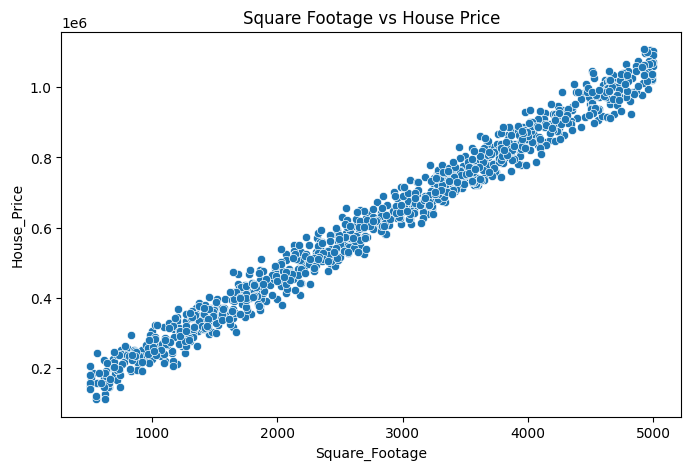

In [22]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Square_Footage",y="House_Price",data=df)
plt.title("Square Footage vs House Price")
plt.show()

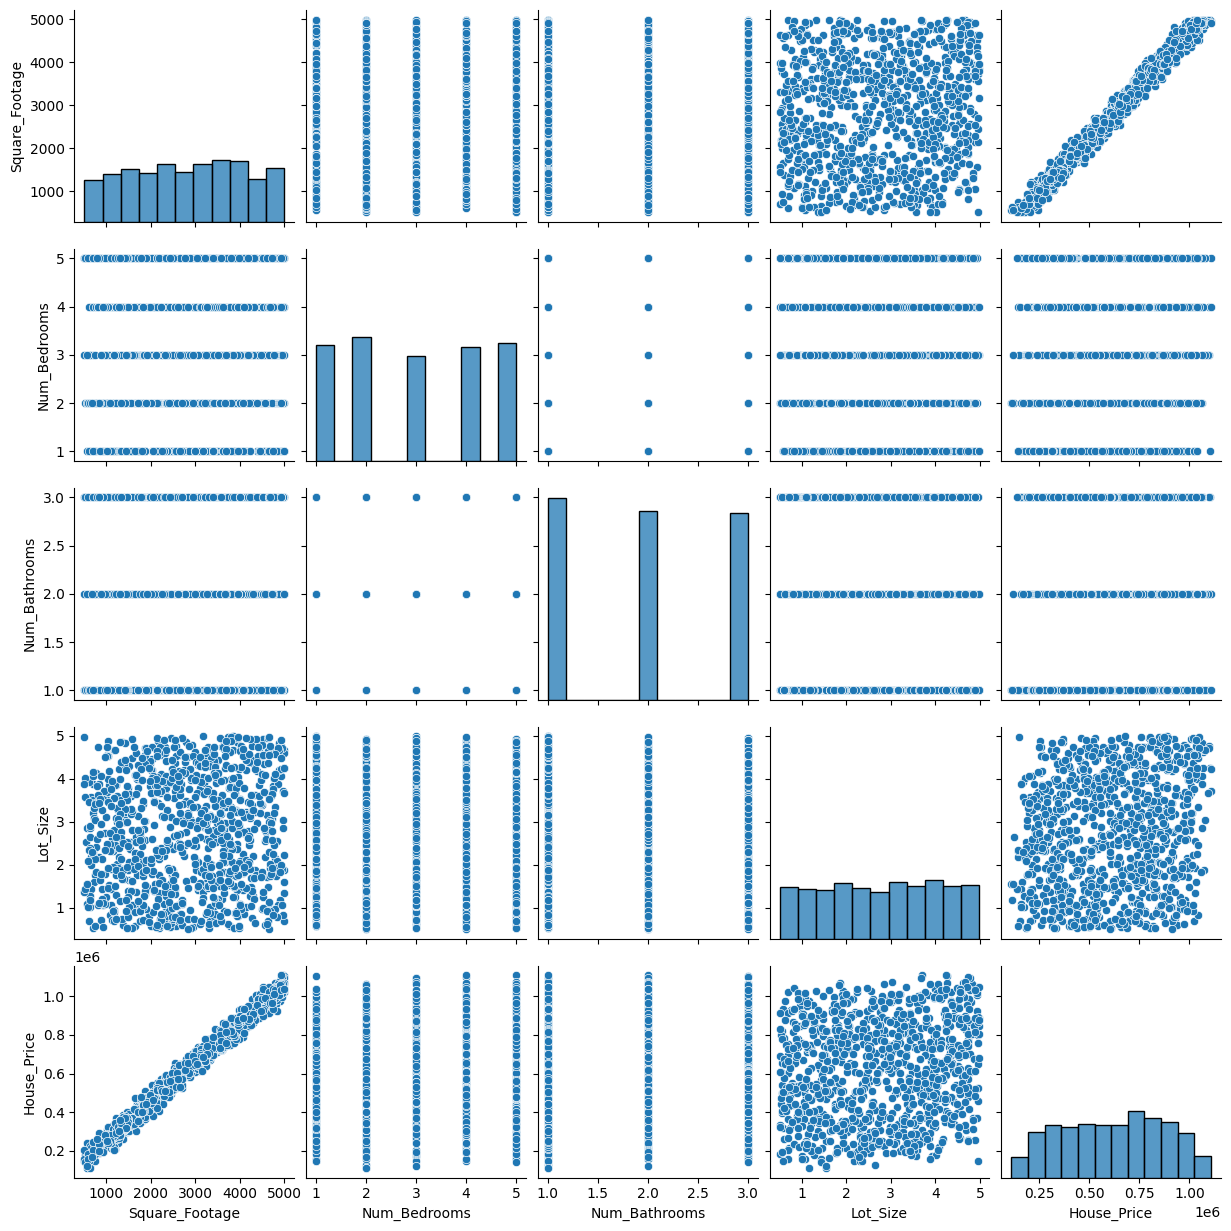

In [23]:
sns.pairplot(df[["Square_Footage","Num_Bedrooms","Num_Bathrooms","Lot_Size","House_Price"]])
plt.show()

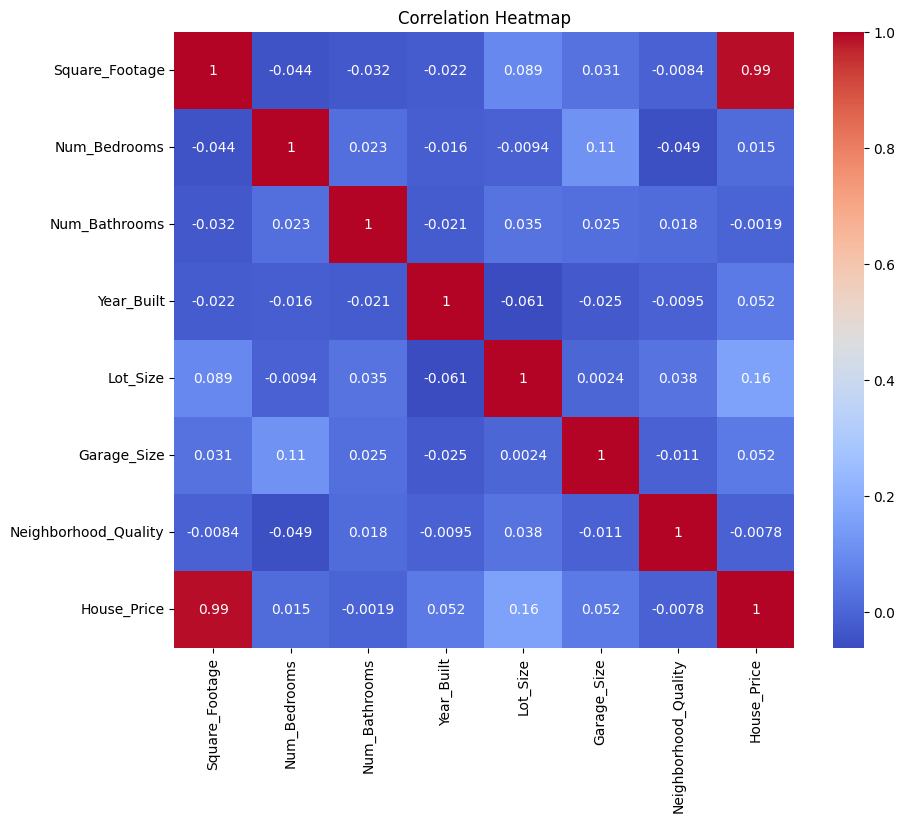

In [24]:
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [7]:
X = df.drop("House_Price",axis=1)
y = df["House_Price"]

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled,columns=X.columns)
X_scaled.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality
0,-1.159803,-0.693836,-1.186699,-0.269122,-1.679278,-1.254658,-0.213126
1,1.160724,0.007008,1.252559,1.428045,1.522390,-0.027008,0.133420
2,0.618843,-1.394681,0.032930,1.428045,0.660422,-1.254658,1.173060
3,-1.473776,-1.394681,0.032930,-0.463084,-0.036555,-0.027008,0.826514
4,1.681887,-0.693836,-1.186699,0.312764,1.480809,-1.254658,0.826514


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print("R^2 Score :", r2_score(y_test, lr_pred))

R^2 Score : 0.9984263636823408


In [11]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
print("R^2 Score :", r2_score(y_test, dt_pred))

R^2 Score : 0.9849578447417716


In [12]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("R^2 Score :", r2_score(y_test, dt_pred))

R^2 Score : 0.9849578447417716


In [13]:
print("Linear Regression :", r2_score(y_test, lr_pred))
print("Decision Tree :", r2_score(y_test, dt_pred))
print("Random Forest :",r2_score(y_test, rf_pred))


Linear Regression : 0.9984263636823408
Decision Tree : 0.9849578447417716
Random Forest : 0.993879177554655


In [14]:
print("MAE :",mean_absolute_error(y_test,lr_pred))
print("MSE :",mean_squared_error(y_test,lr_pred))
print("RMSE :",np.sqrt(mean_squared_error(y_test,lr_pred)))


MAE : 8174.583600008741
MSE : 101434798.50566845
RMSE : 10071.4844241387


In [16]:
new_house = pd.DataFrame({"Square_Footage":[2500],"Num_Bedrooms":[4],"Num_Bathrooms":[3],"Year_Built":[2018],"Lot_Size":[6000],
"Garage_Size":[2],"Neighborhood_Quality":[8]})
new_house_scaled = scaler.transform(new_house)
predicted_price = lr.predict(new_house_scaled)
print("Predicted House Price:",predicted_price[0])

Predicted House Price: 66830012.60586816
